In [1]:
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
res_path = Path("/home/tblanchard/phd/Finsler-Embedding/results/ablation_neighbours")
all_runs = list(res_path.glob("*"))
all_runs

[]

In [3]:
def load_metrics(run_path):
    with open(run_path / "res_alpha_ratio.json", "r") as f:
        alpha_ratio = json.load(f)
    with open(run_path / "res_cosine_similarity_deep.json", "r") as f:
        cosine_similarity_deep = json.load(f)
    with open(run_path / "res_delta_rhs_norm.json", "r") as f:
        delta_rhs_norm = json.load(f)
    with open(run_path / "res_LF_value_constant.json", "r") as f:
        lf_value_constant = json.load(f)
    with open(run_path / "res_ratio_rhs_mean.json", "r") as f:
        ratio_rhs = json.load(f)
    return alpha_ratio, cosine_similarity_deep, delta_rhs_norm, lf_value_constant, ratio_rhs

res = {}
for run in all_runs:
    n = int(run.name.split("_")[1])
    try:
        alpha_ratio, cosine_similarity_deep, delta_rhs_norm, lf_value_constant, ratio_rhs = load_metrics(run)
    except FileNotFoundError:
        print(f"Metrics not found for run: {run}")
        continue

    res[n] = {
        "alpha_ratio": alpha_ratio,
        "cosine_similarity_deep": cosine_similarity_deep,
        "delta_rhs_norm": delta_rhs_norm,
        "lf_value_constant": lf_value_constant,
        "ratio_rhs": ratio_rhs
    }

In [4]:
def res_to_long_df(res):
    """
    Converts a nested results dictionary into a long-format Pandas DataFrame.
    
    Input structure:
    res = {
        (100, 100): {
            'quantity_A': {'mean': 0.5, 'min': 0.1, 'max': 0.9, 'std': 0.1},
            'quantity_B': {'mean': 0.8, 'min': 0.6, 'max': 0.9, 'std': 0.05},
        },
        (n, K): { ... }
    }
    """
    rows = []
    for n, quantities in res.items():
        for quant_name, metrics in quantities.items():
            for metric_name, value in metrics.items():
                rows.append({
                    'n': n,
                    'Quantity': quant_name,
                    'Metric': metric_name,
                    'Value': value
                })
    
    return pd.DataFrame(rows)

df = res_to_long_df(res)
df.sort_values(by=['n', 'Quantity', 'Metric'], inplace=True)
df

KeyError: 'n'

In [ ]:
def plot_quantity_metrics(df, quantity_name,log_scale=False,figax:tuple=None,title:str=None):

    if figax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig, ax = figax
    # 1. Filter and Pivot data
    # We want a dataframe where index is 'n' and columns are the metrics
    df_q = df[df['Quantity'] == quantity_name]
    df_pivot = df_q.pivot(index='n', columns='Metric', values='Value').sort_index()
    
    ax.plot(df_pivot.index, df_pivot['mean'], marker='o', color='#1f77b4', 
             linewidth=2, label='Mean', zorder=3)
    ax.fill_between(df_pivot.index, df_pivot['quantile_25'], df_pivot['quantile_75'], 
                     color='#1f77b4', alpha=0.5, label='25th-75th Percentile', zorder=2)
    
    ax.fill_between(df_pivot.index, df_pivot['quantile_5'], df_pivot['quantile_95'], 
                     color='#1f77b4', alpha=0.3, label='5th-95th Percentile', zorder=2)
    
    ax.fill_between(df_pivot.index, df_pivot['min'], df_pivot['max'], 
                     color='#1f77b4', alpha=0.1, label='Min-Max Range', zorder=1)
    
    if title is not None:
        ax.set_title(title, fontsize=14, fontweight='bold')
    else:
        ax.set_title(f"Analysis of {quantity_name}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Number of neighbors (n)", fontsize=12)
    ax.set_ylabel("Value", fontsize=12)
    ax.grid(True, which="both", ls="-", alpha=0.5)
    ax.legend()
    
    # Optional: Use log scale if the values span several orders of magnitude
    if log_scale:
        ax.set_yscale('symlog', linthresh=1.0) 
    
    fig.tight_layout()
    return fig, ax


In [ ]:
colnames_to_title = {
    "lf_value_constant": r"$\mathbb{E}[L[1](x_i)]$",
    "delta_rhs_norm": r'$\|Lf_k(x_i) - c_k^m <v_{true}(x_i), \nabla f_k(x_i)>\|$',
    "ratio_rhs": r'$\frac{Lf_k(x_i)}{c_km <v_{true}(x_i), \nabla f_k(x_i)>}$',
    "alpha_ratio": r'$<v_{deep}(x_i), v_{true}(x_i)> / \|v_{true}(x_i)\|^2$',
    "cosine_similarity_deep": r"$\text{cosim}(b_{deep}, b_{true})$",
}

In [ ]:
df[(df.Quantity == "ratio_rhs") & (df.Metric == "mean")]

,n,Quantity,Metric,Value
351,-1,ratio_rhs,mean,0.720246
261,5,ratio_rhs,mean,0.356334
126,10,ratio_rhs,mean,0.239986
306,15,ratio_rhs,mean,0.258066
81,20,ratio_rhs,mean,0.470974
36,25,ratio_rhs,mean,0.532258
396,30,ratio_rhs,mean,1.029659
171,50,ratio_rhs,mean,0.250245
216,100,ratio_rhs,mean,0.356280


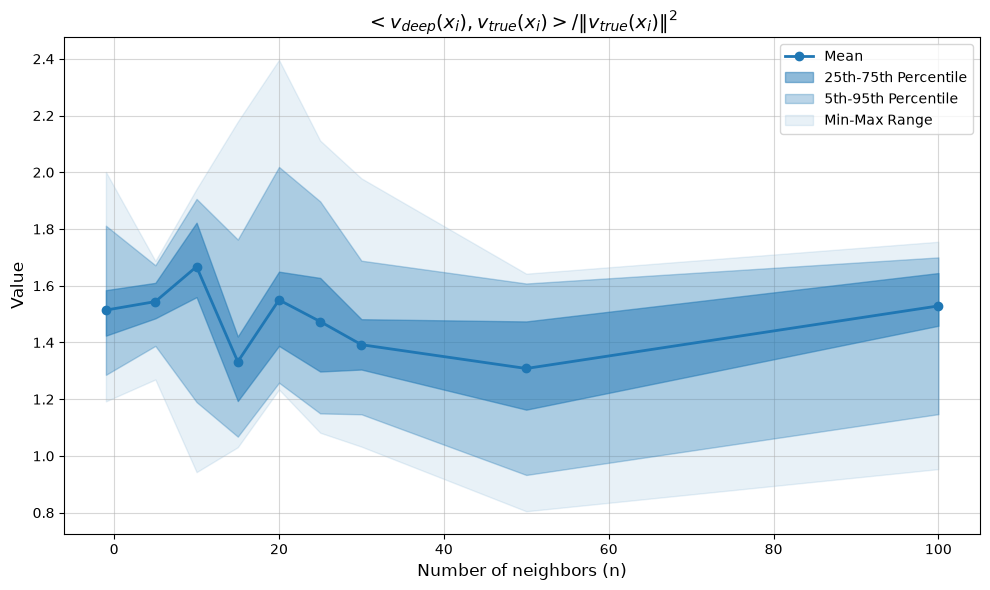

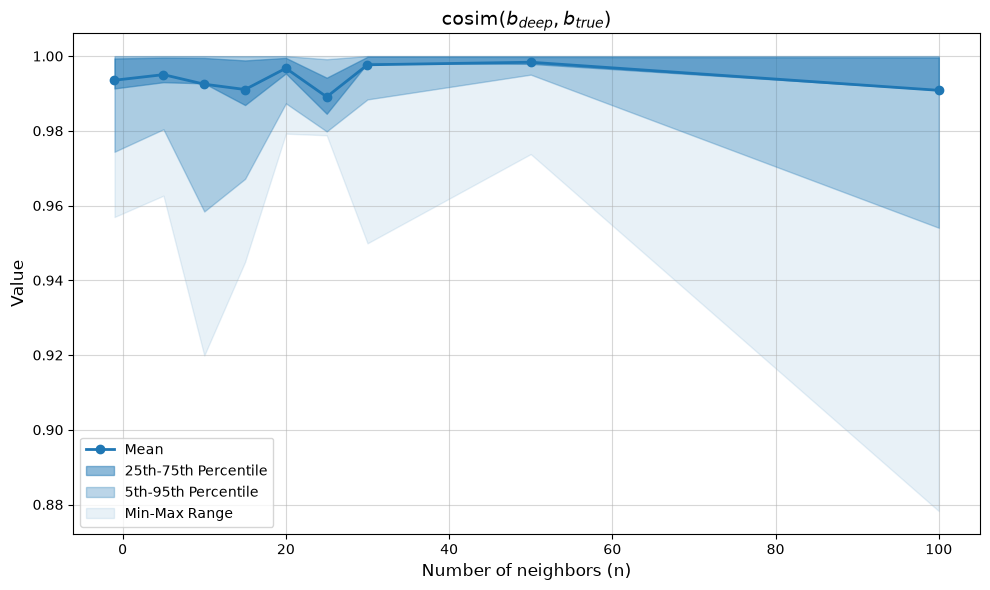

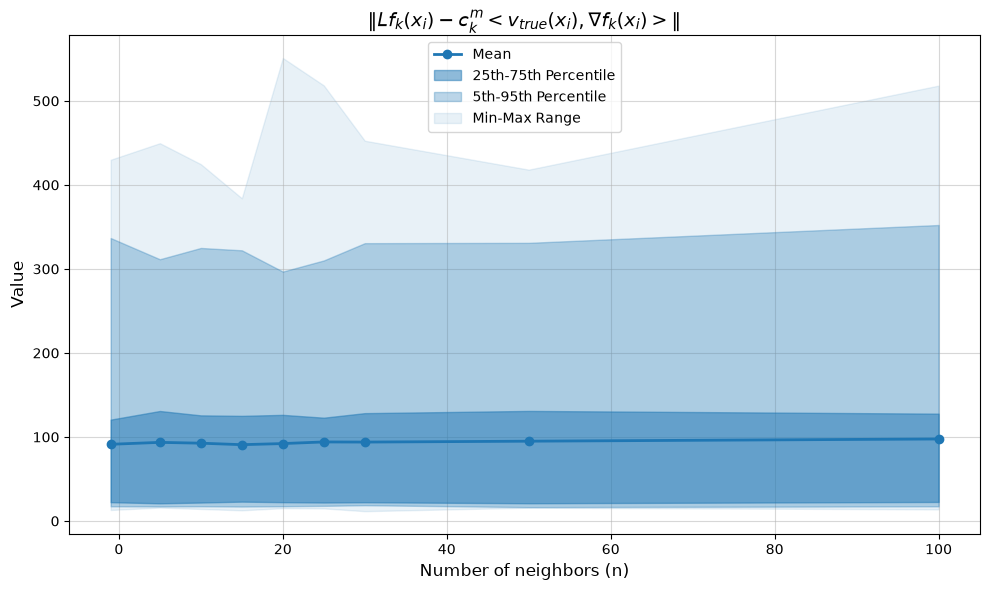

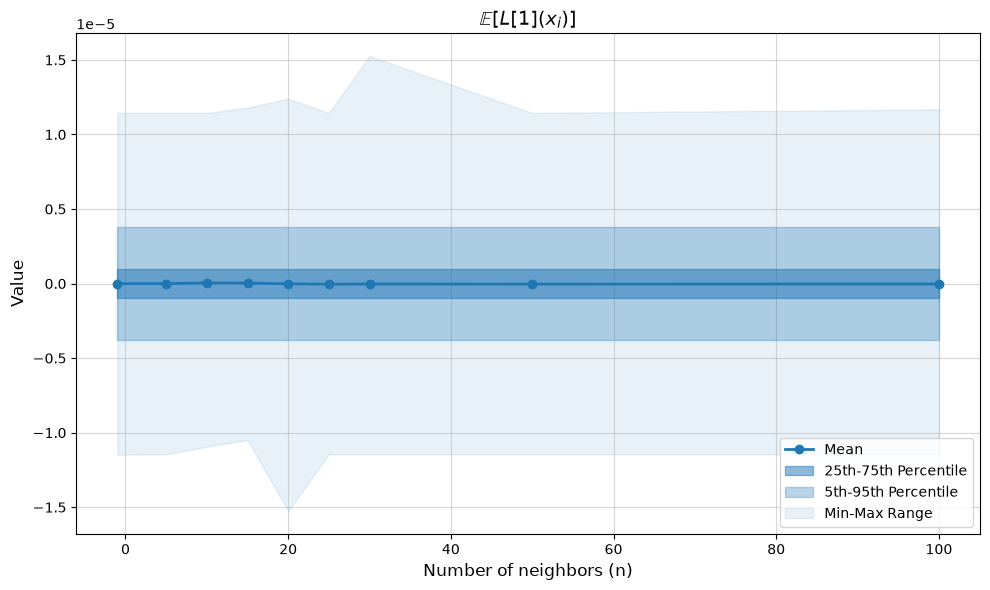

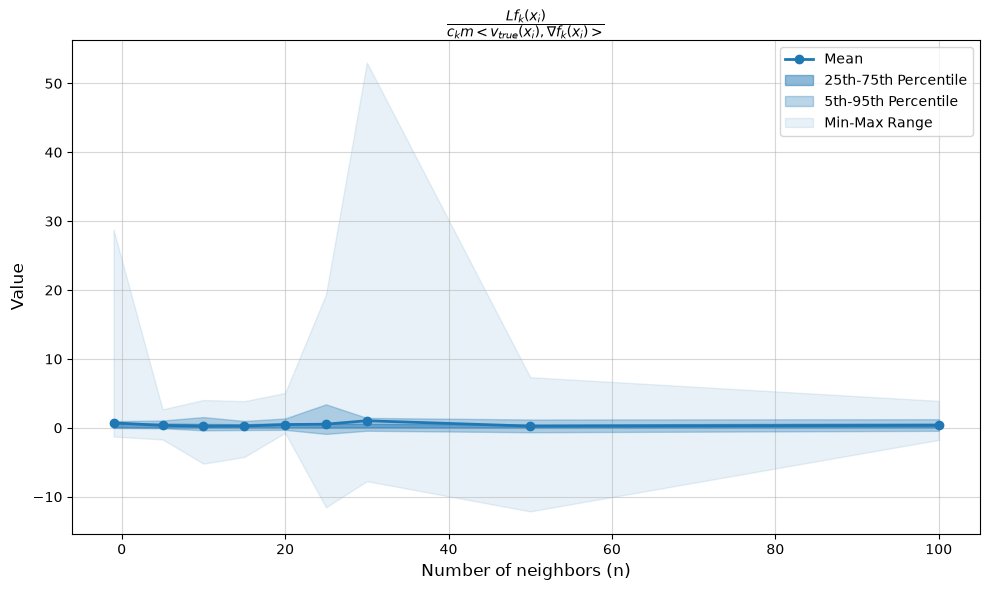

In [ ]:
K= 100
for qqt in df['Quantity'].unique():
    fig,ax = plot_quantity_metrics(df, qqt,title=colnames_to_title.get(qqt, qqt))
    plt.show()